SpendWise AI - Notebook 03: Transaction Classifier

**Objective:** Fine-tune BERT to classify bank transactions into spending categories

**Model:** DistilBERT (smaller, faster BERT) + Custom classification heads

**Target:** 95%+ accuracy on 12 main categories

**What you'll learn:**
- How BERT tokenization works
- Fine-tuning pre-trained models
- Multi-task learning (predicting 2 outputs)
- Training loop from scratch


#1. Imports & Setup


In [15]:
import json
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

# PyTorch
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW

# Transformers
from transformers import AutoTokenizer, AutoModel, get_linear_schedule_with_warmup

# Sklearn for metrics
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score

# Reproducibility
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(42)

# Settings
import warnings
warnings.filterwarnings('ignore')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

# Project root: works whether run from spendwise-ai/ or spendwise-ai/src/ or parent
PROJECT_ROOT = Path.cwd()
if (PROJECT_ROOT / "data").exists() and (PROJECT_ROOT / "src").exists():
    pass
elif PROJECT_ROOT.name == "src" and (PROJECT_ROOT.parent / "data").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
elif (PROJECT_ROOT / "spendwise-ai" / "data").exists():
    PROJECT_ROOT = PROJECT_ROOT / "spendwise-ai"
(PROJECT_ROOT / "data" / "processed").mkdir(parents=True, exist_ok=True)
(PROJECT_ROOT / "models" / "classifier_model").mkdir(parents=True, exist_ok=True)


Device: cpu


# 2. Load Prepared Data from Notebook 01


In [16]:
# Load train/val/test splits
train_df = pd.read_csv(PROJECT_ROOT / "data/processed/train.csv")
val_df = pd.read_csv(PROJECT_ROOT / "data/processed/val.csv")
test_df = pd.read_csv(PROJECT_ROOT / "data/processed/test.csv")

# Load label mappings
with open(PROJECT_ROOT / "data/processed/label_mappings.json", 'r') as f:
    label_mappings = json.load(f)

print("Data loaded!")
print(f"   Train: {len(train_df):,} samples")
print(f"   Val: {len(val_df):,} samples")
print(f"   Test: {len(test_df):,} samples")
print(f"\n   Categories: {len(label_mappings['category_to_id'])}")
print(f"   Subcategories: {len(label_mappings['subcategory_to_id'])}")


Data loaded!
   Train: 85,927 samples
   Val: 18,413 samples
   Test: 18,414 samples

   Categories: 12
   Subcategories: 54


In [17]:
# Quick look at the data
print("\nSample transactions:")
print(train_df[['text', 'category', 'subcategory']].head(10).to_string())



Sample transactions:
                     text           category   subcategory
0   VALLEY STORE $2564.00          Education       Tuition
1        REST BLUE $90.50      Food & Dining   Restaurants
2       HYDRO ONE $122.00  Bills & Utilities   Electricity
3   MOUNTAIN STORE $13.97          Financial     Bank Fees
4      BUDGET RENT $64.50             Travel    Car Rental
5      METRO STORE $19.04          Education         Books
6  MARRIOTT #8943 $191.00             Travel        Hotels
7  RETURN *PACIFIC $56.00             Income        Refund
8  STARBUCKS #1325 $12.00      Food & Dining  Coffee Shops
9       OAK STORE $120.00      Personal Care     Cosmetics


# 3. Understanding BERT Tokenization

BERT doesn't see text directly. It sees **token IDs**:
```
"STARBUCKS #1234" → [101, 2358, 8945, 1001, 12345, 102]
                     [CLS]  star  bucks  #     1234  [SEP]
```

- **[CLS]**: Special token at start (we use its embedding for classification)
- **[SEP]**: Special token at end (marks sequence boundary)
- **Attention Mask**: 1 = real token, 0 = padding


In [18]:
# Load tokenizer
MODEL_NAME = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

print(f"Tokenizer loaded: {MODEL_NAME}")
print(f"   Vocabulary size: {tokenizer.vocab_size:,} tokens")


Tokenizer loaded: distilbert-base-uncased
   Vocabulary size: 30,522 tokens


In [19]:
# Demonstrate tokenization
sample_text = "STARBUCKS #1234 $5.75"
tokens = tokenizer.tokenize(sample_text)
token_ids = tokenizer.encode(sample_text)

print(f"\nTokenization example:")
print(f"   Original: '{sample_text}'")
print(f"   Tokens: {tokens}")
print(f"   Token IDs: {token_ids}")
print(f"   Decoded back: '{tokenizer.decode(token_ids)}'")



Tokenization example:
   Original: 'STARBUCKS #1234 $5.75'
   Tokens: ['starbucks', '#', '123', '##4', '$', '5', '.', '75']
   Token IDs: [101, 29500, 1001, 13138, 2549, 1002, 1019, 1012, 4293, 102]
   Decoded back: '[CLS] starbucks # 1234 $ 5. 75 [SEP]'


In [20]:
# Full encoding with attention mask
encoding = tokenizer(
    sample_text,
    padding='max_length',
    max_length=32,
    truncation=True,
    return_tensors='pt'
)

print(f"\nFull encoding:")
print(f"   input_ids shape: {encoding['input_ids'].shape}")
print(f"   input_ids: {encoding['input_ids'][0][:15].tolist()}...")
print(f"   attention_mask: {encoding['attention_mask'][0][:15].tolist()}...")
print(f"   (1 = real token, 0 = padding)")



Full encoding:
   input_ids shape: torch.Size([1, 32])
   input_ids: [101, 29500, 1001, 13138, 2549, 1002, 1019, 1012, 4293, 102, 0, 0, 0, 0, 0]...
   attention_mask: [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0]...
   (1 = real token, 0 = padding)


# 4. PyTorch Dataset Class


In [21]:
class TransactionDataset(Dataset):
    """
    PyTorch Dataset for transaction classification
    
    Converts text + labels into tokenized tensors
    """
    
    def __init__(self, df: pd.DataFrame, tokenizer, max_length: int = 64):
        self.texts = df['text'].tolist()
        self.category_labels = df['category_id'].astype(int).tolist()
        self.subcategory_labels = df['subcategory_id'].astype(int).tolist()
        self.tokenizer = tokenizer
        self.max_length = max_length
    
    def __len__(self):
        return len(self.texts)
    
    def __getitem__(self, idx):
        encoding = self.tokenizer(
            str(self.texts[idx]),
            truncation=True,
            padding='max_length',
            max_length=self.max_length,
            return_tensors='pt'
        )
        
        return {
            'input_ids': encoding['input_ids'].squeeze(0),
            'attention_mask': encoding['attention_mask'].squeeze(0),
            'category_label': torch.tensor(self.category_labels[idx], dtype=torch.long),
            'subcategory_label': torch.tensor(self.subcategory_labels[idx], dtype=torch.long),
        }


In [22]:
# Create datasets
train_dataset = TransactionDataset(train_df, tokenizer)
val_dataset = TransactionDataset(val_df, tokenizer)
test_dataset = TransactionDataset(test_df, tokenizer)

print(f"Datasets created")
print(f"   Train: {len(train_dataset)}")
print(f"   Val: {len(val_dataset)}")
print(f"   Test: {len(test_dataset)}")

# Verify one sample
sample = train_dataset[0]
print(f"\nSample shapes:")
print(f"   input_ids: {sample['input_ids'].shape}")
print(f"   attention_mask: {sample['attention_mask'].shape}")
print(f"   category_label: {sample['category_label'].item()}")


Datasets created
   Train: 85927
   Val: 18413
   Test: 18414

Sample shapes:
   input_ids: torch.Size([64])
   attention_mask: torch.Size([64])
   category_label: 1


# 5. Build the Classifier Model

Architecture:
```
Input IDs → DistilBERT → [CLS] embedding → Classification Heads → Predictions
```

We have TWO classification heads (multi-task learning):
- Category head: 12 classes
- Subcategory head: 45 classes


In [23]:
class TransactionClassifier(nn.Module):
    """
    Multi-task BERT classifier for transactions
    
    Predicts both category (12 classes) and subcategory (45 classes)
    """
    
    def __init__(self, model_name: str, num_categories: int, num_subcategories: int, dropout: float = 0.3):
        super().__init__()
        
        # Load pre-trained BERT (this is what we fine-tune)
        self.bert = AutoModel.from_pretrained(model_name)
        hidden_size = self.bert.config.hidden_size  # 768 for DistilBERT
        
        # Classification head for main category
        # Linear layers we train from scratch
        self.category_head = nn.Sequential(
            nn.Linear(hidden_size, hidden_size // 2),  # 768 → 384
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_size // 2, num_categories)  # 384 → 12
        )
        
        # Classification head for subcategory
        self.subcategory_head = nn.Sequential(
            nn.Linear(hidden_size, hidden_size // 2),  # 768 → 384
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_size // 2, num_subcategories)  # 384 → 45
        )
    
    def forward(self, input_ids, attention_mask):
        """
        Forward pass
        
        Args:
            input_ids: Token IDs [batch_size, seq_length]
            attention_mask: Attention mask [batch_size, seq_length]
            
        Returns:
            category_logits: [batch_size, num_categories]
            subcategory_logits: [batch_size, num_subcategories]
        """
        # Get BERT outputs
        outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        
        # Get [CLS] token embedding (first token)
        # outputs.last_hidden_state shape: [batch, seq_len, hidden_size]
        cls_embedding = outputs.last_hidden_state[:, 0, :]  # [batch, hidden_size]
        
        # Pass through classification heads
        category_logits = self.category_head(cls_embedding)
        subcategory_logits = self.subcategory_head(cls_embedding)
        
        return category_logits, subcategory_logits


In [24]:
# Initialize model
num_categories = len(label_mappings['category_to_id'])
num_subcategories = len(label_mappings['subcategory_to_id'])

model = TransactionClassifier(
    model_name=MODEL_NAME,
    num_categories=num_categories,
    num_subcategories=num_subcategories
)
model.to(device)

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Model initialized")
print(f"   Total parameters: {total_params:,}")
print(f"   Trainable parameters: {trainable_params:,}")
print(f"   Categories: {num_categories}")
print(f"   Subcategories: {num_subcategories}")


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Model initialized
   Total parameters: 66,978,882
   Trainable parameters: 66,978,882
   Categories: 12
   Subcategories: 54


# 6. Training Configuration

Key hyperparameters:
- **Batch size**: How many samples per update (32 is good balance)
- **Learning rate**: How big the weight updates are (2e-5 is standard for BERT)
- **Epochs**: How many times we see the full dataset (3-5 is usually enough)
- **Warmup**: Gradually increase learning rate at start (prevents instability)


In [25]:
# Hyperparameters
BATCH_SIZE = 32
LEARNING_RATE = 2e-5
NUM_EPOCHS = 3
WARMUP_RATIO = 0.1

# Create data loaders (handles batching, shuffling)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

# Optimizer (AdamW is standard for transformers)
optimizer = AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=0.01)

# Learning rate scheduler with warmup
total_steps = len(train_loader) * NUM_EPOCHS
warmup_steps = int(total_steps * WARMUP_RATIO)

scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=warmup_steps,
    num_training_steps=total_steps
)

# Loss function (CrossEntropyLoss for multi-class classification)
criterion = nn.CrossEntropyLoss()

print(f"Training configuration:")
print(f"   Batch size: {BATCH_SIZE}")
print(f"   Learning rate: {LEARNING_RATE}")
print(f"   Epochs: {NUM_EPOCHS}")
print(f"   Total steps: {total_steps}")
print(f"   Warmup steps: {warmup_steps}")
print(f"   Batches per epoch: {len(train_loader)}")


Training configuration:
   Batch size: 32
   Learning rate: 2e-05
   Epochs: 3
   Total steps: 8058
   Warmup steps: 805
   Batches per epoch: 2686


# 7. Training Functions

Two functions:
- `train_epoch()`: One pass through training data (update weights)
- `evaluate()`: One pass through validation data (no weight updates)


In [26]:
def train_epoch(model, dataloader, optimizer, scheduler, criterion, device):
    """Train for one epoch"""
    model.train()  # Set to training mode (enables dropout)
    
    total_loss = 0
    cat_correct = 0
    subcat_correct = 0
    total_samples = 0
    
    progress = tqdm(dataloader, desc="Training", leave=False)
    
    for batch in progress:
        # Move data to device
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        cat_labels = batch['category_label'].to(device)
        subcat_labels = batch['subcategory_label'].to(device)
        
        # Zero gradients
        optimizer.zero_grad()
        
        # Forward pass
        cat_logits, subcat_logits = model(input_ids, attention_mask)
        
        # Calculate loss (weighted combination of both tasks)
        cat_loss = criterion(cat_logits, cat_labels)
        subcat_loss = criterion(subcat_logits, subcat_labels)
        loss = 0.6 * cat_loss + 0.4 * subcat_loss  # Weight category more
        
        # Backward pass
        loss.backward()
        
        # Gradient clipping (prevents exploding gradients)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        
        # Update weights
        optimizer.step()
        scheduler.step()
        
        # Track metrics
        total_loss += loss.item()
        cat_preds = cat_logits.argmax(dim=1)
        subcat_preds = subcat_logits.argmax(dim=1)
        cat_correct += (cat_preds == cat_labels).sum().item()
        subcat_correct += (subcat_preds == subcat_labels).sum().item()
        total_samples += len(cat_labels)
        
        # Update progress bar
        progress.set_postfix({
            'loss': f'{loss.item():.4f}',
            'cat_acc': f'{cat_correct/total_samples:.3f}'
        })
    
    return {
        'loss': total_loss / len(dataloader),
        'cat_accuracy': cat_correct / total_samples,
        'subcat_accuracy': subcat_correct / total_samples
    }


In [27]:
def evaluate(model, dataloader, criterion, device):
    """Evaluate on validation/test set"""
    model.eval()  # Set to evaluation mode (disables dropout)
    
    total_loss = 0
    all_cat_preds = []
    all_cat_labels = []
    all_subcat_preds = []
    all_subcat_labels = []
    
    with torch.no_grad():  # No gradient computation needed
        for batch in tqdm(dataloader, desc="Evaluating", leave=False):
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            cat_labels = batch['category_label'].to(device)
            subcat_labels = batch['subcategory_label'].to(device)
            
            # Forward pass
            cat_logits, subcat_logits = model(input_ids, attention_mask)
            
            # Loss
            cat_loss = criterion(cat_logits, cat_labels)
            subcat_loss = criterion(subcat_logits, subcat_labels)
            loss = 0.6 * cat_loss + 0.4 * subcat_loss
            total_loss += loss.item()
            
            # Predictions
            all_cat_preds.extend(cat_logits.argmax(dim=1).cpu().numpy())
            all_cat_labels.extend(cat_labels.cpu().numpy())
            all_subcat_preds.extend(subcat_logits.argmax(dim=1).cpu().numpy())
            all_subcat_labels.extend(subcat_labels.cpu().numpy())
    
    return {
        'loss': total_loss / len(dataloader),
        'cat_accuracy': accuracy_score(all_cat_labels, all_cat_preds),
        'subcat_accuracy': accuracy_score(all_subcat_labels, all_subcat_preds),
        'cat_f1': f1_score(all_cat_labels, all_cat_preds, average='weighted'),
        'cat_preds': all_cat_preds,
        'cat_labels': all_cat_labels,
    }


# 8. Train the Model!

This is where the actual learning happens.


In [28]:
# Track training history
history = {
    'train_loss': [], 'val_loss': [],
    'train_cat_acc': [], 'val_cat_acc': [],
    'train_subcat_acc': [], 'val_subcat_acc': []
}

best_val_acc = 0
best_model_state = None

print("Starting training...")
print("=" * 60)

for epoch in range(NUM_EPOCHS):
    print(f"\nEpoch {epoch + 1}/{NUM_EPOCHS}")
    
    # Train
    train_metrics = train_epoch(model, train_loader, optimizer, scheduler, criterion, device)
    
    # Evaluate
    val_metrics = evaluate(model, val_loader, criterion, device)
    
    # Track history
    history['train_loss'].append(train_metrics['loss'])
    history['val_loss'].append(val_metrics['loss'])
    history['train_cat_acc'].append(train_metrics['cat_accuracy'])
    history['val_cat_acc'].append(val_metrics['cat_accuracy'])
    history['train_subcat_acc'].append(train_metrics['subcat_accuracy'])
    history['val_subcat_acc'].append(val_metrics['subcat_accuracy'])
    
    # Print results
    print(f"   Train Loss: {train_metrics['loss']:.4f} | Val Loss: {val_metrics['loss']:.4f}")
    print(f"   Train Cat Acc: {train_metrics['cat_accuracy']:.4f} | Val Cat Acc: {val_metrics['cat_accuracy']:.4f}")
    print(f"   Train SubCat Acc: {train_metrics['subcat_accuracy']:.4f} | Val SubCat Acc: {val_metrics['subcat_accuracy']:.4f}")
    
    # Save best model
    if val_metrics['cat_accuracy'] > best_val_acc:
        best_val_acc = val_metrics['cat_accuracy']
        best_model_state = model.state_dict().copy()
        print(f"New best model saved! Accuracy: {best_val_acc:.4f}")

print("\n" + "=" * 60)
print(f"Training complete! Best validation accuracy: {best_val_acc:.4f}")


Starting training...

Epoch 1/3


   Train Loss: 0.6410 | Val Loss: 0.1481
   Train Cat Acc: 0.8658 | Val Cat Acc: 0.9450
   Train SubCat Acc: 0.7722 | Val SubCat Acc: 0.9161
New best model saved! Accuracy: 0.9450

Epoch 2/3


   Train Loss: 0.1430 | Val Loss: 0.1340
   Train Cat Acc: 0.9458 | Val Cat Acc: 0.9467
   Train SubCat Acc: 0.9196 | Val SubCat Acc: 0.9216
New best model saved! Accuracy: 0.9467

Epoch 3/3


   Train Loss: 0.1354 | Val Loss: 0.1317
   Train Cat Acc: 0.9473 | Val Cat Acc: 0.9467
   Train SubCat Acc: 0.9217 | Val SubCat Acc: 0.9248

Training complete! Best validation accuracy: 0.9467


# 9. Visualize Training Progress


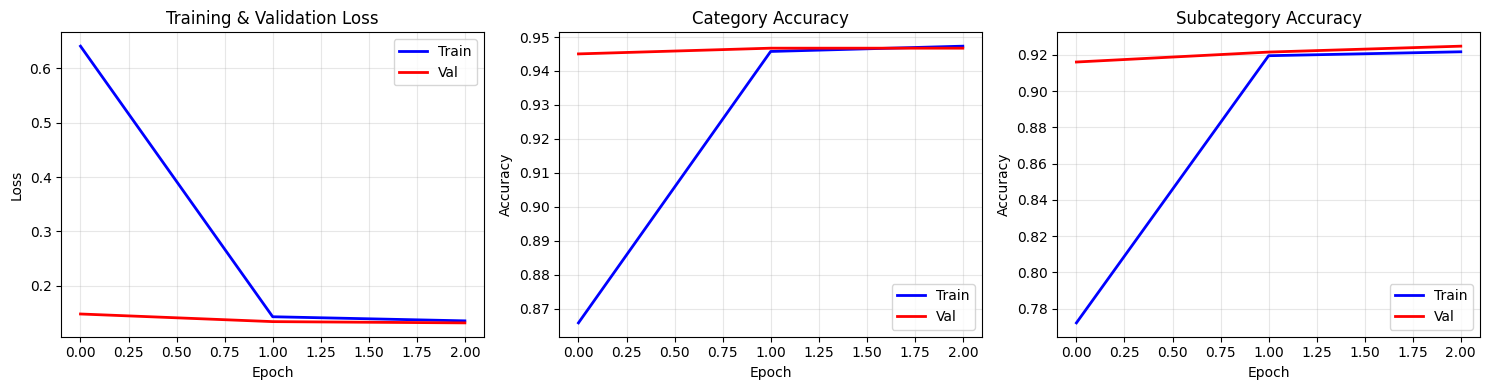

In [29]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Loss
axes[0].plot(history['train_loss'], 'b-', label='Train', linewidth=2)
axes[0].plot(history['val_loss'], 'r-', label='Val', linewidth=2)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training & Validation Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Category Accuracy
axes[1].plot(history['train_cat_acc'], 'b-', label='Train', linewidth=2)
axes[1].plot(history['val_cat_acc'], 'r-', label='Val', linewidth=2)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Category Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Subcategory Accuracy
axes[2].plot(history['train_subcat_acc'], 'b-', label='Train', linewidth=2)
axes[2].plot(history['val_subcat_acc'], 'r-', label='Val', linewidth=2)
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('Accuracy')
axes[2].set_title('Subcategory Accuracy')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(PROJECT_ROOT / "models/classifier_model/training_history.png", dpi=150, bbox_inches='tight')
plt.show()


# 10. Final Evaluation on Test Set


In [30]:
# Load best model
model.load_state_dict(best_model_state)

# Evaluate on test set
print("📊 Evaluating on test set...")
test_metrics = evaluate(model, test_loader, criterion, device)

print(f"\nTest Results:")
print(f"   Category Accuracy: {test_metrics['cat_accuracy']:.4f} ({test_metrics['cat_accuracy']*100:.1f}%)")
print(f"   Category F1 Score: {test_metrics['cat_f1']:.4f}")
print(f"   Subcategory Accuracy: {test_metrics['subcat_accuracy']:.4f} ({test_metrics['subcat_accuracy']*100:.1f}%)")


📊 Evaluating on test set...



Test Results:
   Category Accuracy: 0.9484 (94.8%)
   Category F1 Score: 0.9492
   Subcategory Accuracy: 0.9263 (92.6%)


In [31]:
# Classification report
print("\n Classification Report (Categories):\n")

category_names = [label_mappings['id_to_category'][str(i)] for i in range(num_categories)]
print(classification_report(
    test_metrics['cat_labels'],
    test_metrics['cat_preds'],
    target_names=category_names
))



 Classification Report (Categories):

                   precision    recall  f1-score   support

Bills & Utilities       1.00      1.00      1.00      1102
        Education       0.56      0.65      0.60       895
    Entertainment       1.00      1.00      1.00      1126
        Financial       0.87      0.55      0.67       857
    Food & Dining       1.00      1.00      1.00      4058
Health & Wellness       1.00      1.00      1.00      1118
           Income       1.00      1.00      1.00       883
    Personal Care       0.50      0.62      0.56       669
         Shopping       1.00      1.00      1.00      1333
    Subscriptions       1.00      1.00      1.00       764
   Transportation       1.00      1.00      1.00      4763
           Travel       1.00      1.00      1.00       846

         accuracy                           0.95     18414
        macro avg       0.91      0.90      0.90     18414
     weighted avg       0.95      0.95      0.95     18414



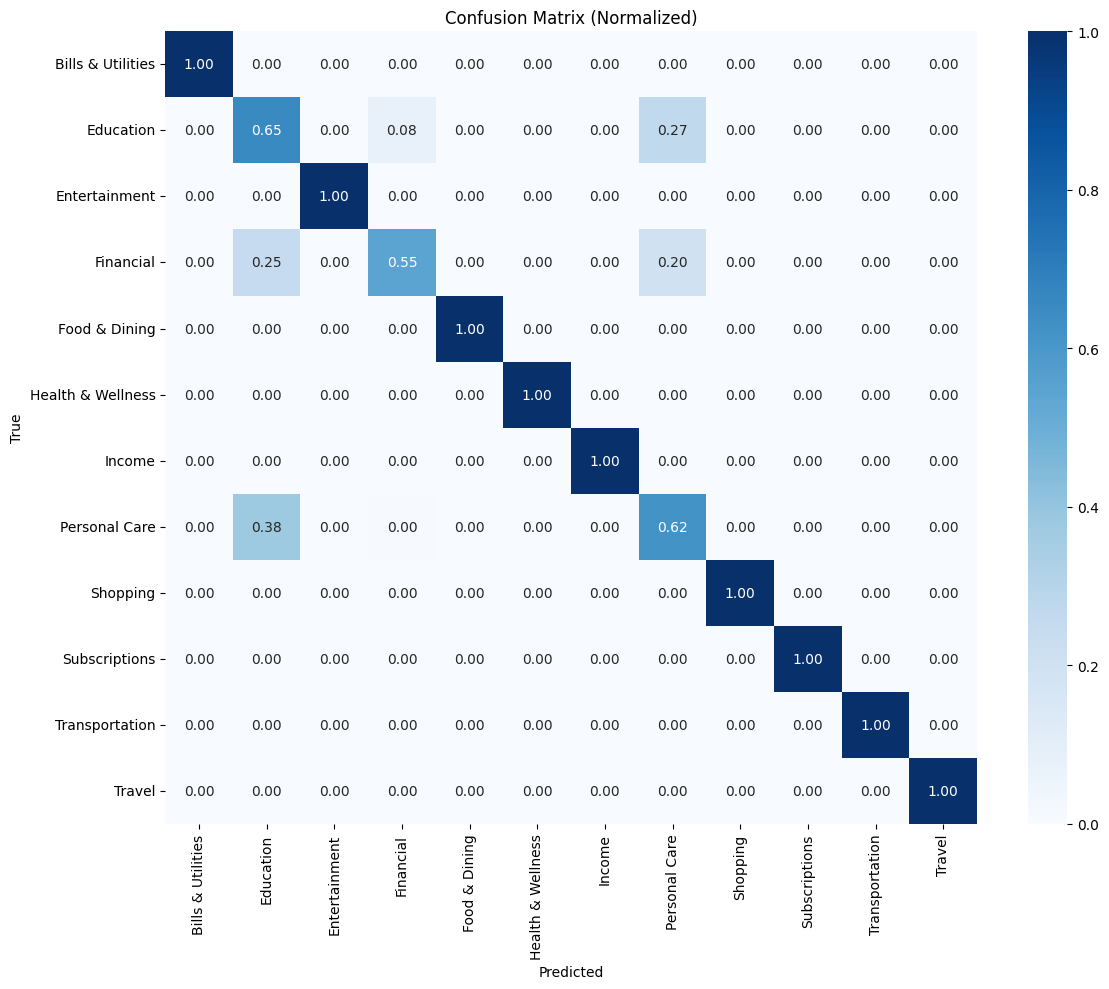

In [32]:
# Confusion matrix
plt.figure(figsize=(12, 10))
cm = confusion_matrix(test_metrics['cat_labels'], test_metrics['cat_preds'])
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

sns.heatmap(cm_normalized, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=category_names, yticklabels=category_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix (Normalized)')
plt.tight_layout()
plt.savefig(PROJECT_ROOT / "models/classifier_model/confusion_matrix.png", dpi=150, bbox_inches='tight')
plt.show()


# 11. Save Model for Production


In [33]:
# Create save directory
save_path = PROJECT_ROOT / "models/classifier_model"
save_path.mkdir(parents=True, exist_ok=True)

# Save model checkpoint
torch.save({
    'model_state_dict': best_model_state,
    'label_mappings': label_mappings,
    'config': {
        'model_name': MODEL_NAME,
        'num_categories': num_categories,
        'num_subcategories': num_subcategories,
    },
    'metrics': {
        'test_cat_accuracy': test_metrics['cat_accuracy'],
        'test_subcat_accuracy': test_metrics['subcat_accuracy'],
    }
}, save_path / "model.pt")

# Save tokenizer
tokenizer.save_pretrained(save_path)

print(f" Model saved to {save_path}")


 Model saved to /Users/patel/Documents/E/MPS Sem 5/EAI 6020/Final_Project/spendwise-ai/models/classifier_model


# 12. Build Inference Class for Production


In [34]:
class TransactionClassifierInference:
    """
    Production-ready transaction classifier
    
    Usage:
        classifier = TransactionClassifierInference("path/to/model")
        result = classifier.classify("STARBUCKS #1234 $5.75")
    """
    
    def __init__(self, model_path: str):
        self.device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        
        # Load checkpoint
        checkpoint = torch.load(f"{model_path}/model.pt", map_location=self.device)
        self.label_mappings = checkpoint['label_mappings']
        config = checkpoint['config']
        
        # Load tokenizer
        self.tokenizer = AutoTokenizer.from_pretrained(model_path)
        
        # Initialize model
        self.model = TransactionClassifier(
            model_name=config['model_name'],
            num_categories=config['num_categories'],
            num_subcategories=config['num_subcategories']
        )
        self.model.load_state_dict(checkpoint['model_state_dict'])
        self.model.to(self.device)
        self.model.eval()
    
    def classify(self, text: str) -> dict:
        """Classify a single transaction"""
        
        # Tokenize
        encoding = self.tokenizer(
            text,
            truncation=True,
            padding='max_length',
            max_length=64,
            return_tensors='pt'
        )
        
        input_ids = encoding['input_ids'].to(self.device)
        attention_mask = encoding['attention_mask'].to(self.device)
        
        # Predict
        with torch.no_grad():
            cat_logits, subcat_logits = self.model(input_ids, attention_mask)
        
        # Get predictions with confidence
        cat_probs = F.softmax(cat_logits, dim=1)
        subcat_probs = F.softmax(subcat_logits, dim=1)
        
        cat_id = cat_logits.argmax(dim=1).item()
        subcat_id = subcat_logits.argmax(dim=1).item()
        
        return {
            'category': self.label_mappings['id_to_category'][str(cat_id)],
            'category_confidence': cat_probs[0, cat_id].item(),
            'subcategory': self.label_mappings['id_to_subcategory'][str(subcat_id)],
            'subcategory_confidence': subcat_probs[0, subcat_id].item(),
        }
    
    def classify_batch(self, texts: list) -> list:
        """Classify multiple transactions"""
        return [self.classify(t) for t in texts]


# 13. Test the Inference Class


In [35]:
print("Testing inference class...\n")

classifier = TransactionClassifierInference(str(save_path))

# Test transactions (including ones NOT in training data)
test_transactions = [
    "STARBUCKS #1234 $5.75",
    "UBER *TRIP $23.50",
    "AMAZON.COM*MK4H2 $156.99",
    "NETFLIX.COM $15.99",
    "SHELL #5678 $45.00",
    "COSTCO WHSE #123 $234.56",
    "SPOTIFY $9.99",
    "WALGREENS #789 $12.34",
    # These are completely new patterns:
    "PEETS COFFEE SF $6.25",
    "LYFT RIDE $18.00",
    "TRADER JOES #456 $87.50",
]

print(" Classification Results:")
print("=" * 70)

for txn in test_transactions:
    result = classifier.classify(txn)
    print(f"\n'{txn}'")
    print(f"   → {result['category']} ({result['category_confidence']:.1%})")
    print(f"   → {result['subcategory']} ({result['subcategory_confidence']:.1%})")


Testing inference class...



Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


 Classification Results:

'STARBUCKS #1234 $5.75'
   → Food & Dining (100.0%)
   → Coffee Shops (100.0%)

'UBER *TRIP $23.50'
   → Transportation (100.0%)
   → Rideshare (100.0%)

'AMAZON.COM*MK4H2 $156.99'
   → Shopping (100.0%)
   → Amazon (99.9%)

'NETFLIX.COM $15.99'
   → Subscriptions (99.9%)
   → Streaming (99.5%)

'SHELL #5678 $45.00'
   → Transportation (100.0%)
   → Gas & Fuel (99.9%)

'COSTCO WHSE #123 $234.56'
   → Shopping (100.0%)
   → Department Stores (99.9%)

'SPOTIFY $9.99'
   → Subscriptions (99.9%)
   → Streaming (99.6%)

'WALGREENS #789 $12.34'
   → Health & Wellness (100.0%)
   → Pharmacy (99.8%)

'PEETS COFFEE SF $6.25'
   → Food & Dining (100.0%)
   → Coffee Shops (89.1%)

'LYFT RIDE $18.00'
   → Transportation (100.0%)
   → Rideshare (99.9%)

'TRADER JOES #456 $87.50'
   → Food & Dining (89.2%)
   → Fast Food (94.2%)


# 14. Save Inference Module


In [36]:
# Save the classifier module for use in the app
module_code = '''
Transaction Classifier Module - SpendWise AI

Fine-tuned DistilBERT for transaction categorization.


import torch
import torch.nn as nn
import torch.nn.functional as F
from transformers import AutoTokenizer, AutoModel


class TransactionClassifier(nn.Module):
    """Multi-task BERT classifier"""
    
    def __init__(self, model_name, num_categories, num_subcategories, dropout=0.3):
        super().__init__()
        self.bert = AutoModel.from_pretrained(model_name)
        hidden_size = self.bert.config.hidden_size
        
        self.category_head = nn.Sequential(
            nn.Linear(hidden_size, hidden_size // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_size // 2, num_categories)
        )
        
        self.subcategory_head = nn.Sequential(
            nn.Linear(hidden_size, hidden_size // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_size // 2, num_subcategories)
        )
    
    def forward(self, input_ids, attention_mask):
        outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        cls_embedding = outputs.last_hidden_state[:, 0, :]
        return self.category_head(cls_embedding), self.subcategory_head(cls_embedding)


class TransactionClassifierInference:
    """Production-ready classifier"""
    
    def __init__(self, model_path):
        self.device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        checkpoint = torch.load(f"{model_path}/model.pt", map_location=self.device)
        self.label_mappings = checkpoint['label_mappings']
        config = checkpoint['config']
        
        self.tokenizer = AutoTokenizer.from_pretrained(model_path)
        self.model = TransactionClassifier(
            config['model_name'], config['num_categories'], config['num_subcategories']
        )
        self.model.load_state_dict(checkpoint['model_state_dict'])
        self.model.to(self.device)
        self.model.eval()
    
    def classify(self, text):
        encoding = self.tokenizer(text, truncation=True, padding='max_length', 
                                   max_length=64, return_tensors='pt')
        input_ids = encoding['input_ids'].to(self.device)
        attention_mask = encoding['attention_mask'].to(self.device)
        
        with torch.no_grad():
            cat_logits, subcat_logits = self.model(input_ids, attention_mask)
        
        cat_probs = F.softmax(cat_logits, dim=1)
        subcat_probs = F.softmax(subcat_logits, dim=1)
        cat_id = cat_logits.argmax(dim=1).item()
        subcat_id = subcat_logits.argmax(dim=1).item()
        
        return {
            'category': self.label_mappings['id_to_category'][str(cat_id)],
            'category_confidence': cat_probs[0, cat_id].item(),
            'subcategory': self.label_mappings['id_to_subcategory'][str(subcat_id)],
            'subcategory_confidence': subcat_probs[0, subcat_id].item(),
        }

'''

with open(PROJECT_ROOT / "src/transaction_classifier.py", 'w') as f:
    f.write(module_code)

print(f" Module saved to src/transaction_classifier.py")


 Module saved to src/transaction_classifier.py
